In [38]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt  
import seaborn as sns 


## Data Analytics

In [46]:
df = pd.read_csv('titanic_data_updated.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,no,third,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,yes,first,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,yes,third,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,yes,first,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,no,third,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,no,second,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,yes,first,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,no,third,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,yes,first,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [28]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.drop_duplicates(inplace=True)

# Univarite Analysis

<Axes: xlabel='Survived', ylabel='count'>

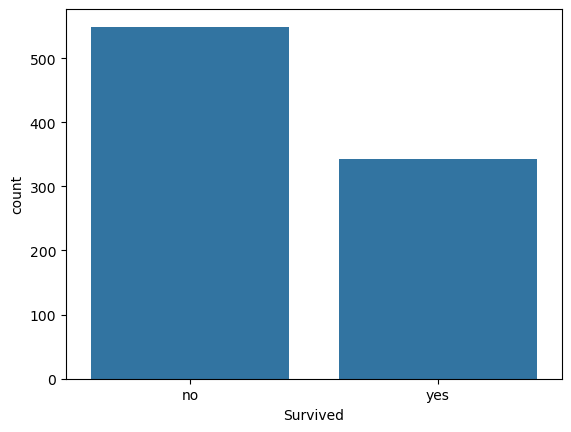

In [9]:
sns.countplot(data=df,x='Survived')

In [10]:
survived_data = df['Survived'].value_counts()
print(survived_data)

Survived
no     549
yes    342
Name: count, dtype: int64


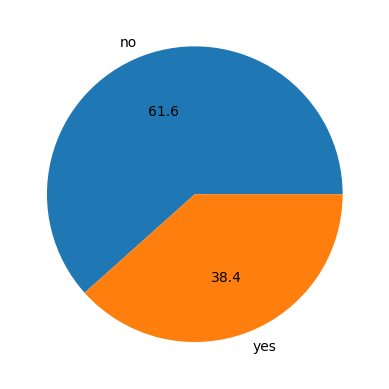

In [14]:
show_labels = df['Survived'].unique()
plt.pie(survived_data,labels=show_labels,autopct="%1.1f")
plt.show()

In [18]:
(df['Sex'].value_counts())/(len(df))*100

Sex
male      64.758698
female    35.241302
Name: count, dtype: float64

In [19]:
(df['Survived'].value_counts()/len(df)) *100

Survived
no     61.616162
yes    38.383838
Name: count, dtype: float64

In [20]:
(df['Pclass'].value_counts()/len(df)) *100

Pclass
third     55.106622
first     24.242424
second    20.650954
Name: count, dtype: float64

# Numerical Verticate Analysis

Text(0, 0.5, 'Probability')

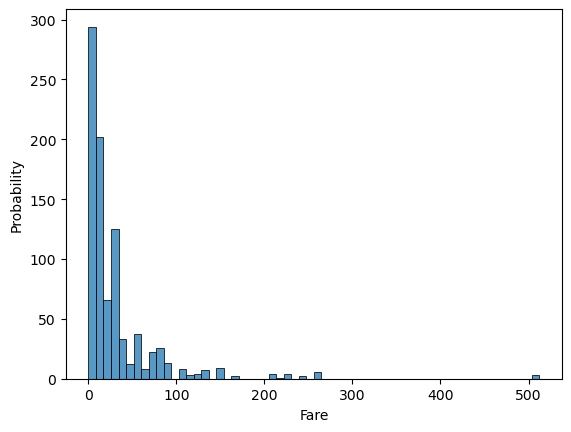

In [24]:
sns.histplot(df['Fare'])
plt.xlabel('Fare')
plt.ylabel('Probability')

# Box Plot

<Axes: ylabel='Fare'>

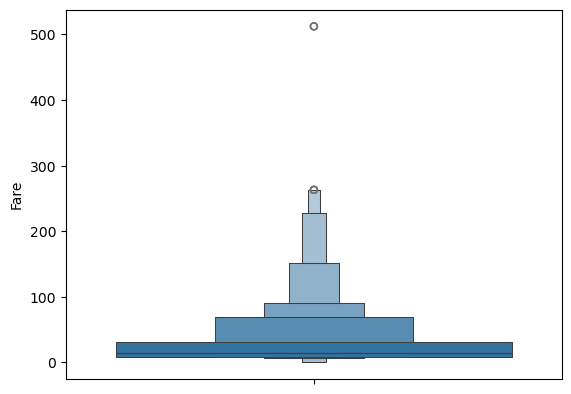

In [25]:
sns.boxenplot(df['Fare'])

# Multivarite 

<Axes: xlabel='Sex', ylabel='count'>

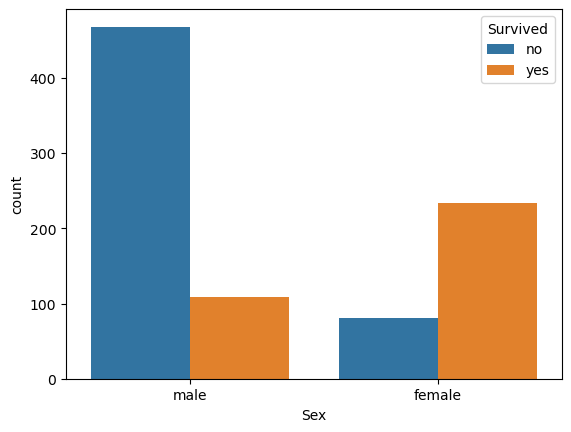

In [30]:
sns.countplot(x=df['Sex'],hue=df['Survived'])

In [33]:
gender_split = df.groupby('Sex')['Survived'].value_counts(normalize=True)
gender_split

Sex     Survived
female  yes         0.742038
        no          0.257962
male    no          0.811092
        yes         0.188908
Name: proportion, dtype: float64

In [34]:
data_frame = sns.load_dataset('tips')
data_frame

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='total_bill', ylabel='tip'>

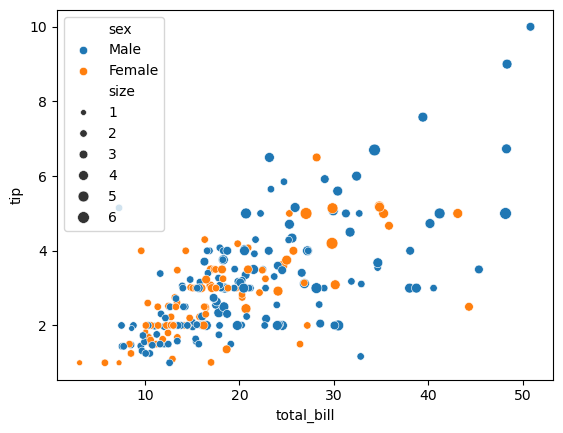

In [45]:
sns.scatterplot(data=data_frame,
                x = 'total_bill',
                y='tip',hue='sex',
                size='size') 

In [47]:
from ydata_profiling import ProfileReport
profile = ProfileReport(df, title='Titanic Profile report')
profile.to_file('titanic.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 12/12 [00:00<00:00, 207.51it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]